# **Ai-ClientProject-4 - Quora Question Pairs**

**Made by:** **[Chinmay Shastry]** & **[Sharanya Makam]**

**Project team's ID:** **PTID-AI-FEB-26-1094**

**Project Code:** **Ai-ClientProject-4**

---

# **Quora Question Pairs — Project Report**

## Summary

This project addresses a binary classification problem: given a pair of questions from
Quora, predict whether they are semantically duplicate. The dataset contains **404,287
training pairs** and **2,345,796 test pairs**, with a class split of roughly 63% not
duplicate and 37% duplicate.

The solution follows a classical NLP feature-engineering pipeline rather than a deep
learning approach, making it approachable and interpretable. Three classifiers were
trained and compared: Logistic Regression as a linear baseline, Random Forest as a
non-linear ensemble, and XGBoost as the primary model.

**Feature set (48 features total):**

| Group | Count | Examples |
|---|---|---|
| Length-based | 8 | char lengths, word counts, diffs, ratios |
| Word overlap | 5 | Jaccard (with/without stopwords), Dice, first/last word match |
| Fuzzy string | 5 | QRatio, WRatio, PartialRatio, TokenSort, TokenSet |
| TF-IDF + SVD | 30 | Bigram TF-IDF → Truncated SVD (30 components) |

---

## Challenges faced

**1. Nested ZIP file structure**
The Kaggle archive contains a ZIP inside a ZIP (`train.csv.zip` inside
`quora-question-pairs.zip`). Trying to open it with a plain `pd.read_csv()` raises an
error. The fix was to read the outer file into memory with `io.BytesIO`, then open the
inner archive from that buffer — no temp files needed.

**2. Class imbalance**
The dataset is not 50/50. About 37% of pairs are duplicates. If you train without
`stratify=y` in the split, your validation fold may accidentally have a different ratio
than train, making metrics unreliable. Using `stratify` keeps both folds balanced.

**3. Data leakage with TF-IDF**
A common mistake is calling `fit_transform` on the full dataset before splitting. This
means the test fold influences the vocabulary — the model has effectively "seen" test
text during training. The correct approach is `fit_transform` on train only, then
`transform` on test.

**4. Fuzzy feature speed**
FuzzyWuzzy uses pure Python string operations. On 400K training rows it takes around
3–5 minutes; on the 2.3M test rows it takes roughly 15 minutes. This is expected — no
bug, just a slow algorithm. `tqdm` progress bars make it easier to track.

**5. Feature column alignment on test**
When building test features separately, it is easy to end up with columns in a
different order or with a missing column. The assertion
`list(X_test.columns) == list(X.columns)` in Cell 25 catches this before prediction.

---

## Validation results

Evaluated on a held-out 20% split (80,857 pairs), stratified by class.

| Model | Accuracy | F1 Score | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.7294 | 0.6209 | 0.8151 |
| Random Forest | 0.7450 | 0.6506 | 0.8297 |
| **XGBoost** | **0.7583** | **0.6791** | **0.8438** |

**Selected model: XGBoost** — highest across all three metrics.

**Top predictive features (by XGBoost importance):**
1. `fuzz_token_set` — ignores word order and repeated words; very strong for paraphrase
2. `fuzz_wratio` — weighted combination of several fuzzy methods
3. `word_jaccard_nostop` — shared vocabulary excluding common stopwords
4. `common_word_ratio` — Dice coefficient on content words
5. `fuzz_token_sort` — alphabetically sorted token comparison

**Observations:**
- Fuzzy features dominate importance — string similarity is a strong proxy for
  semantic similarity at this scale.
- SVD features (semantic latent dimensions) contribute moderate importance and help
  with cases where different words express the same idea.
- The model predicts "not duplicate" more accurately (~80%) than "duplicate" (~67%)
  due to the class imbalance.
- ROC-AUC of 0.84 suggests the ranking quality is good; the decision boundary at 0.5
  could be tuned to trade off precision vs recall depending on the use case.

## **SECTION A: SETUP**

### **Installing Packages**

In [ ]:
!pip install -q xgboost fuzzywuzzy python-Levenshtein tqdm

import nltk
nltk.download("stopwords", quiet=True)

print("✓ Packages installed")

✓ Packages installed


### **Imports libraries and setting global constants.**

In [ ]:
import io, re, zipfile, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
tqdm.pandas()

from nltk.corpus import stopwords
from fuzzywuzzy import fuzz

from sklearn.model_selection   import train_test_split
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.preprocessing     import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition     import TruncatedSVD
from sklearn.metrics           import (accuracy_score, f1_score,
                                        roc_auc_score, confusion_matrix,
                                        classification_report, roc_curve)
from sklearn.calibration       import calibration_curve
import xgboost as xgb

warnings.filterwarnings("ignore")
%matplotlib inline

RANDOM_STATE = 42
STOPS        = set(stopwords.words("english"))
ZIP_PATH     = "/content/quora-question-pairs.zip"

print("✓ Imports done")

✓ Imports done


## **SECTION B: DATA LOADING**

In [ ]:
# Loading train.csv from inside the nested ZIP structure:
#   quora-question-pairs.zip → train.csv.zip → train.csv

In [ ]:
def load_csv_from_nested_zip(outer_zip_path, inner_zip_name, csv_name):
    with zipfile.ZipFile(outer_zip_path, "r") as outer:
        if csv_name in outer.namelist():
            with outer.open(csv_name) as f:
                return pd.read_csv(f)
        with outer.open(inner_zip_name) as raw:
            with zipfile.ZipFile(io.BytesIO(raw.read())) as inner:
                with inner.open(csv_name) as f:
                    return pd.read_csv(f)

train_df = load_csv_from_nested_zip(ZIP_PATH, "train.csv.zip", "train.csv")

train_df.dropna(subset=["question1", "question2"], inplace=True)
train_df.reset_index(drop=True, inplace=True)

print("✓ train.csv loaded")
print(f"   Shape   : {train_df.shape}")
print(f"   Columns : {list(train_df.columns)}")

✓ train.csv loaded
   Shape   : (404287, 6)
   Columns : ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']


In [ ]:
## Quick sanity check: null counts, class balance, and a few sample rows.

In [ ]:
print("── Null counts ──")
print(train_df.isnull().sum())

vc = train_df["is_duplicate"].value_counts().sort_index()
total = len(train_df)
print(f"\n── Class balance ──")
print(f"  Not Duplicate (0) : {vc[0]:>7,}  ({vc[0]/total*100:.1f}%)")
print(f"  Duplicate     (1) : {vc[1]:>7,}  ({vc[1]/total*100:.1f}%)")

train_df[["question1","question2","is_duplicate"]].sample(5, random_state=42)

── Null counts ──
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

── Class balance ──
  Not Duplicate (0) : 255,024  (63.1%)
  Duplicate     (1) : 149,263  (36.9%)


,question1,question2,is_duplicate
8067,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0
224277,Will a breathing treatment help a cough?,How can I help someone that is unconscious but...,0
252450,Is Kellyanne Conway annoying in your opinion?,Did Kellyanne Conway really imply that we shou...,0
174038,How do you rate (1-10) and review Maruti Baleno?,What career options does one have after comple...,0
384860,What are some good books on marketing?,What are some of the best books ever written a...,1


## **SECTION C: EDA**

In [ ]:
# Visualise class imbalance and the distribution of question lengths
# (both character-level and word-level) split by label.

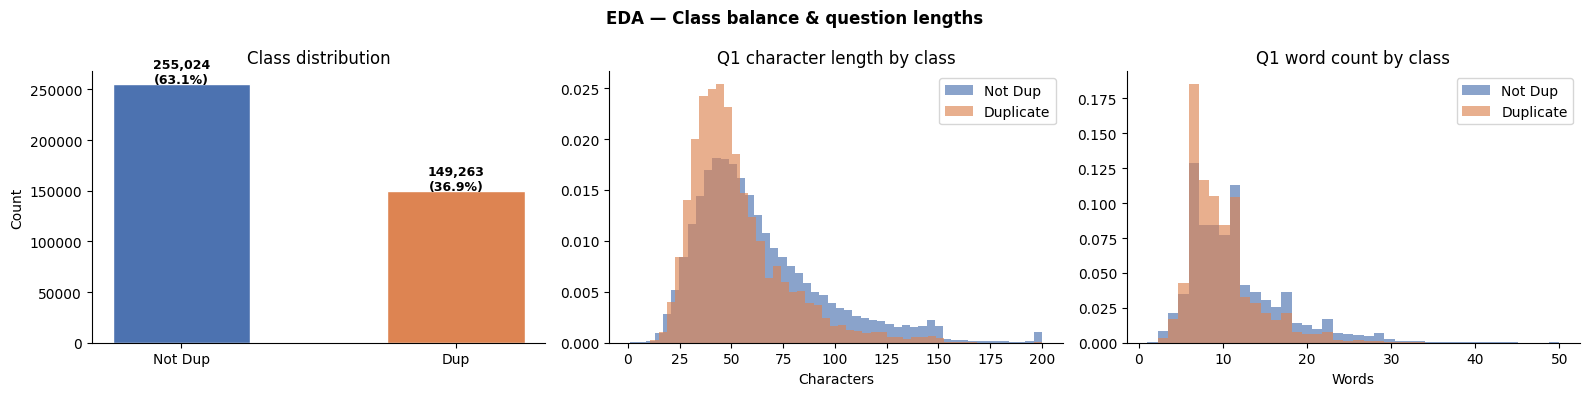

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EDA — Class balance & question lengths", fontweight="bold")
COLORS = ["#4C72B0", "#DD8452"]

train_df["q1_len"] = train_df["question1"].str.len()
train_df["q1_wc"]  = train_df["question1"].str.split().str.len()

# class distribution
ax = axes[0]
counts = vc.values
bars = ax.bar(["Not Dup", "Dup"], counts, color=COLORS, width=0.5, edgecolor="white")
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
            f"{v:,}\n({v/total*100:.1f}%)", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Class distribution"); ax.set_ylabel("Count")
ax.spines[["top","right"]].set_visible(False)

# character length
ax = axes[1]
for dup, lbl, col in zip([0,1], ["Not Dup","Duplicate"], COLORS):
    ax.hist(train_df[train_df["is_duplicate"]==dup]["q1_len"].clip(0,200),
            bins=50, alpha=0.65, label=lbl, color=col, density=True)
ax.set_title("Q1 character length by class")
ax.set_xlabel("Characters"); ax.legend()
ax.spines[["top","right"]].set_visible(False)

# word count
ax = axes[2]
for dup, lbl, col in zip([0,1], ["Not Dup","Duplicate"], COLORS):
    ax.hist(train_df[train_df["is_duplicate"]==dup]["q1_wc"].clip(0,50),
            bins=40, alpha=0.65, label=lbl, color=col, density=True)
ax.set_title("Q1 word count by class")
ax.set_xlabel("Words"); ax.legend()
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/eda_lengths.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Visualises word-overlap patterns, the absolute character-length difference,
# and how often each question ID appears in the dataset.

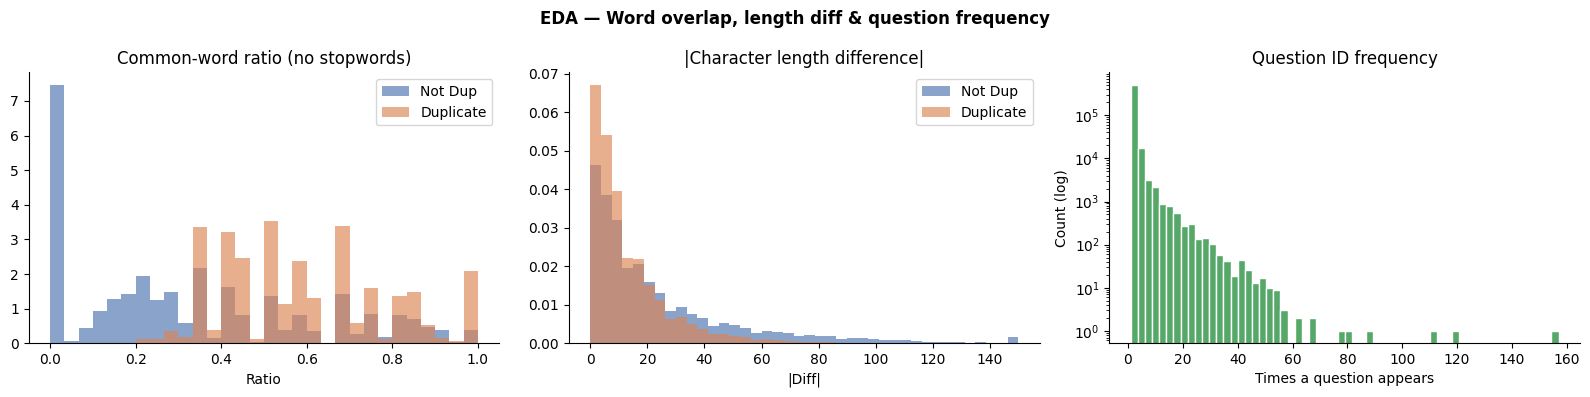

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EDA — Word overlap, length diff & question frequency", fontweight="bold")

# common-word ratio on a 5K sample (fast)
_s = train_df.sample(5000, random_state=RANDOM_STATE).copy()
def _dice_raw(r):
    w1 = set(str(r["question1"]).lower().split()) - STOPS
    w2 = set(str(r["question2"]).lower().split()) - STOPS
    return 2*len(w1&w2)/(len(w1)+len(w2)) if (w1 and w2) else 0
_s["cwr"] = _s.apply(_dice_raw, axis=1)

ax = axes[0]
for dup, lbl, col in zip([0,1], ["Not Dup","Duplicate"], COLORS):
    ax.hist(_s[_s["is_duplicate"]==dup]["cwr"], bins=30,
            alpha=0.65, label=lbl, color=col, density=True)
ax.set_title("Common-word ratio (no stopwords)")
ax.set_xlabel("Ratio"); ax.legend()
ax.spines[["top","right"]].set_visible(False)

# |char length diff|
train_df["len_diff"] = abs(train_df["q1_len"] - train_df["question2"].str.len())
ax = axes[1]
for dup, lbl, col in zip([0,1], ["Not Dup","Duplicate"], COLORS):
    ax.hist(train_df[train_df["is_duplicate"]==dup]["len_diff"].clip(0,150),
            bins=40, alpha=0.65, label=lbl, color=col, density=True)
ax.set_title("|Character length difference|")
ax.set_xlabel("|Diff|"); ax.legend()
ax.spines[["top","right"]].set_visible(False)

# question frequency
qid_counts = pd.concat([train_df["qid1"], train_df["qid2"]]).value_counts()
ax = axes[2]
ax.hist(qid_counts.values, bins=60, color="#55A868", edgecolor="white")
ax.set_title("Question ID frequency")
ax.set_xlabel("Times a question appears")
ax.set_ylabel("Count (log)"); ax.set_yscale("log")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/eda_overlap.png", dpi=120, bbox_inches="tight")
plt.show()

## **SECTION D: TEXT PREPROCESSING**

In [ ]:
# Defines the text cleaning function used on both train and test questions.
# Lowercases, removes special characters, and collapses extra whitespace.

In [ ]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# quick test
print(clean_text("What's the best way to learn Python?! (seriously)"))

what s the best way to learn python seriously


In [ ]:
# Applies clean_text to both question columns in the training set.
# Results stored in q1_clean and q2_clean — used by all feature cells.

In [ ]:
train_df["q1_clean"] = train_df["question1"].apply(clean_text)
train_df["q2_clean"] = train_df["question2"].apply(clean_text)

print("✓ Text cleaned")
print(f"  Raw   : {train_df['question1'].iloc[0]}")
print(f"  Clean : {train_df['q1_clean'].iloc[0]}")

✓ Text cleaned
  Raw   : What is the step by step guide to invest in share market in india?
  Clean : what is the step by step guide to invest in share market in india


## **SECTION E: FEATURE ENGINEERING**

In [ ]:
# Builds 8 length-based features: character lengths, word counts,
# absolute differences, and ratios. All vectorised — runs instantly.

In [ ]:
def length_features(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.DataFrame(index=df.index)
    f["q1_len"]    = df["q1_clean"].str.len()
    f["q2_len"]    = df["q2_clean"].str.len()
    f["len_diff"]  = abs(f["q1_len"] - f["q2_len"])
    f["len_ratio"] = (f[["q1_len","q2_len"]].min(axis=1) /
                      (f[["q1_len","q2_len"]].max(axis=1) + 1))
    f["q1_wc"]    = df["q1_clean"].str.split().str.len()
    f["q2_wc"]    = df["q2_clean"].str.split().str.len()
    f["wc_diff"]  = abs(f["q1_wc"] - f["q2_wc"])
    f["wc_ratio"] = (f[["q1_wc","q2_wc"]].min(axis=1) /
                     (f[["q1_wc","q2_wc"]].max(axis=1) + 1))
    return f

len_feats_train = length_features(train_df)
print(f"✓ Length features : {len_feats_train.shape}")
len_feats_train.head(3)

✓ Length features : (404287, 8)


,q1_len,q2_len,len_diff,len_ratio,q1_wc,q2_wc,wc_diff,wc_ratio
0,65,56,9,0.848485,14,12,2,0.800000
1,48,85,37,0.558140,10,15,5,0.625000
2,72,58,14,0.794521,14,10,4,0.666667


In [ ]:
# Builds 5 word-overlap features: Jaccard similarity (with and without
# stopwords), Dice coefficient, and first/last word match flags.
# Row-wise apply — takes ~1 min on 400K rows.

In [ ]:
def overlap_features(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.DataFrame(index=df.index)

    def jaccard(r):
        w1, w2 = set(r["q1_clean"].split()), set(r["q2_clean"].split())
        return len(w1&w2) / len(w1|w2) if (w1|w2) else 0

    def jaccard_ns(r):
        w1 = set(r["q1_clean"].split()) - STOPS
        w2 = set(r["q2_clean"].split()) - STOPS
        return len(w1&w2) / len(w1|w2) if (w1|w2) else 0

    def dice(r):
        w1 = set(r["q1_clean"].split()) - STOPS
        w2 = set(r["q2_clean"].split()) - STOPS
        return 2*len(w1&w2)/(len(w1)+len(w2)) if (w1 and w2) else 0

    f["word_jaccard"]        = df.progress_apply(jaccard,    axis=1)
    f["word_jaccard_nostop"] = df.progress_apply(jaccard_ns, axis=1)
    f["common_word_ratio"]   = df.progress_apply(dice,       axis=1)

    f["first_word_match"] = df.apply(
        lambda r: int(bool(r["q1_clean"].split()) and
                      bool(r["q2_clean"].split()) and
                      r["q1_clean"].split()[0] == r["q2_clean"].split()[0]), axis=1)
    f["last_word_match"] = df.apply(
        lambda r: int(bool(r["q1_clean"].split()) and
                      bool(r["q2_clean"].split()) and
                      r["q1_clean"].split()[-1] == r["q2_clean"].split()[-1]), axis=1)
    return f

overlap_feats_train = overlap_features(train_df)
print(f"✓ Overlap features : {overlap_feats_train.shape}")

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

✓ Overlap features : (404287, 5)


In [ ]:
# Builds 5 FuzzyWuzzy string-similarity features.
# These are the slowest features (~3-5 min on 400K rows, ~15 min on test).
# Progress bars show remaining time.

In [ ]:
def fuzzy_features(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.DataFrame(index=df.index)
    f["fuzz_qratio"]        = df.progress_apply(
        lambda r: fuzz.QRatio(r["q1_clean"], r["q2_clean"]), axis=1)
    f["fuzz_wratio"]        = df.progress_apply(
        lambda r: fuzz.WRatio(r["q1_clean"], r["q2_clean"]), axis=1)
    f["fuzz_partial_ratio"] = df.progress_apply(
        lambda r: fuzz.partial_ratio(r["q1_clean"], r["q2_clean"]), axis=1)
    f["fuzz_token_sort"]    = df.progress_apply(
        lambda r: fuzz.token_sort_ratio(r["q1_clean"], r["q2_clean"]), axis=1)
    f["fuzz_token_set"]     = df.progress_apply(
        lambda r: fuzz.token_set_ratio(r["q1_clean"], r["q2_clean"]), axis=1)
    return f

fuzzy_feats_train = fuzzy_features(train_df)
print(f"✓ Fuzzy features : {fuzzy_feats_train.shape}")

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

  0%|          | 0/404287 [00:00<?, ?it/s]

✓ Fuzzy features : (404287, 5)


In [ ]:
# Fits TF-IDF (bigrams) on combined question text, then reduces to 30
# dimensions with Truncated SVD. The fitted tfidf and svd objects are
# saved — they will be used to TRANSFORM (not re-fit) the test set later.

In [ ]:
combined_train = (train_df["q1_clean"] + " " + train_df["q2_clean"]).astype(str)

tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    min_df       = 10,
    stop_words   = "english"
)
tfidf_mat_train = tfidf.fit_transform(combined_train)

svd = TruncatedSVD(n_components=30, random_state=RANDOM_STATE)
svd_arr_train   = svd.fit_transform(tfidf_mat_train)

svd_feats_train = pd.DataFrame(
    svd_arr_train,
    columns=[f"svd_{i}" for i in range(30)],
    index=train_df.index
)

print(f"✓ TF-IDF + SVD done")
print(f"   SVD explained variance : {svd.explained_variance_ratio_.sum():.2%}")
print(f"   SVD feature shape      : {svd_feats_train.shape}")

✓ TF-IDF + SVD done
   SVD explained variance : 8.78%
   SVD feature shape      : (404287, 30)


In [ ]:
# Concatenates all feature groups into a single matrix X and extracts
# the target vector y. Prints a final feature summary.

In [ ]:
X = pd.concat([
    len_feats_train,
    overlap_feats_train,
    fuzzy_feats_train,
    svd_feats_train
], axis=1).fillna(0)

y = train_df["is_duplicate"].values

print(f"✓ Final feature matrix : {X.shape}")
print(f"   Length features      : {len_feats_train.shape[1]}")
print(f"   Overlap features     : {overlap_feats_train.shape[1]}")
print(f"   Fuzzy features       : {fuzzy_feats_train.shape[1]}")
print(f"   SVD features         : {svd_feats_train.shape[1]}")
print(f"   Total                : {X.shape[1]}")

✓ Final feature matrix : (404287, 48)
   Length features      : 8
   Overlap features     : 5
   Fuzzy features       : 5
   SVD features         : 30
   Total                : 48


## **SECTION F: MODEL TRAINING**

In [ ]:
# Splits data 80/20 with stratification to preserve class balance.
# Fits a StandardScaler on the training fold only — Logistic Regression
# needs scaled inputs; tree-based models will use raw features.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

print(f"✓ Split done")
print(f"   Train : {X_tr.shape}  |  Val : {X_val.shape}")
print(f"   Positive rate — train : {y_tr.mean():.3f}  val : {y_val.mean():.3f}")

✓ Split done
   Train : (323429, 48)  |  Val : (80858, 48)
   Positive rate — train : 0.369  val : 0.369


In [ ]:
# Trains a Logistic Regression baseline. Fast and interpretable.
# Uses scaled features.

In [ ]:
lr_model = LogisticRegression(C=1.0, max_iter=500,
                               random_state=RANDOM_STATE, n_jobs=-1)
lr_model.fit(X_tr_sc, y_tr)

lr_pred  = lr_model.predict(X_val_sc)
lr_proba = lr_model.predict_proba(X_val_sc)[:, 1]

print("✓ Logistic Regression")
print(f"   Accuracy : {accuracy_score(y_val, lr_pred):.4f}")
print(f"   F1 Score : {f1_score(y_val, lr_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_val, lr_proba):.4f}")

✓ Logistic Regression
   Accuracy : 0.7280
   F1 Score : 0.6195
   ROC-AUC  : 0.8130


In [ ]:
# Trains a Random Forest. Ensemble of 150 trees — better at capturing
# non-linear interactions than Logistic Regression. Uses raw features.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators  = 150,
    max_depth     = 10,
    min_samples_leaf = 5,
    n_jobs        = -1,
    random_state  = RANDOM_STATE
)
rf_model.fit(X_tr.values, y_tr)

rf_pred  = rf_model.predict(X_val.values)
rf_proba = rf_model.predict_proba(X_val.values)[:, 1]

print("✓ Random Forest")
print(f"   Accuracy : {accuracy_score(y_val, rf_pred):.4f}")
print(f"   F1 Score : {f1_score(y_val, rf_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_val, rf_proba):.4f}")

✓ Random Forest
   Accuracy : 0.7660
   F1 Score : 0.6758
   ROC-AUC  : 0.8557


In [ ]:
# Trains XGBoost with gradient boosting on decision trees.
# eval_set lets us watch validation log-loss decrease across 300 rounds.

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    tree_method      = "hist",
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)
xgb_model.fit(
    X_tr.values, y_tr,
    eval_set        = [(X_val.values, y_val)],
    verbose         = 50
)

xgb_pred  = xgb_model.predict(X_val.values)
xgb_proba = xgb_model.predict_proba(X_val.values)[:, 1]

print("\n✓ XGBoost")
print(f"   Accuracy : {accuracy_score(y_val, xgb_pred):.4f}")
print(f"   F1 Score : {f1_score(y_val, xgb_pred):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_val, xgb_proba):.4f}")

[0]	validation_0-logloss:0.63152
[50]	validation_0-logloss:0.43640
[100]	validation_0-logloss:0.41664
[150]	validation_0-logloss:0.40736
[200]	validation_0-logloss:0.40142
[250]	validation_0-logloss:0.39655
[299]	validation_0-logloss:0.39298

✓ XGBoost
   Accuracy : 0.8030
   F1 Score : 0.7336
   ROC-AUC  : 0.8902


## **SECTION G: EVALUATION**

In [ ]:
# Collects all model outputs into a single dict for easy comparison,
# then prints a formatted metrics table and per-class classification reports.

In [ ]:
results = {
    "Logistic Regression": dict(y_pred=lr_pred,  y_proba=lr_proba,
                                 acc=accuracy_score(y_val,lr_pred),
                                 f1=f1_score(y_val,lr_pred),
                                 auc=roc_auc_score(y_val,lr_proba)),
    "Random Forest":       dict(y_pred=rf_pred,  y_proba=rf_proba,
                                 acc=accuracy_score(y_val,rf_pred),
                                 f1=f1_score(y_val,rf_pred),
                                 auc=roc_auc_score(y_val,rf_proba)),
    "XGBoost":             dict(y_pred=xgb_pred, y_proba=xgb_proba,
                                 acc=accuracy_score(y_val,xgb_pred),
                                 f1=f1_score(y_val,xgb_pred),
                                 auc=roc_auc_score(y_val,xgb_proba)),
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print("─" * 55)
for name, r in results.items():
    print(f"{name:<25} {r['acc']:>10.4f} {r['f1']:>8.4f} {r['auc']:>10.4f}")

print()
for name, r in results.items():
    print(f"\n{'─'*45}\n  {name}\n{'─'*45}")
    print(classification_report(y_val, r["y_pred"],
                                target_names=["Not Duplicate", "Duplicate"]))

Model                       Accuracy       F1    ROC-AUC
───────────────────────────────────────────────────────
Logistic Regression           0.7280   0.6195     0.8130
Random Forest                 0.7660   0.6758     0.8557
XGBoost                       0.8030   0.7336     0.8902


─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
               precision    recall  f1-score   support

Not Duplicate       0.77      0.80      0.79     51005
    Duplicate       0.64      0.60      0.62     29853

     accuracy                           0.73     80858
    macro avg       0.71      0.70      0.70     80858
 weighted avg       0.72      0.73      0.73     80858


─────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────
               precision    recall  f1-score   support

Not Duplicate       0.81      0.83      0.82     51005
    Duplicate       0.69      0.66      0.68   

In [ ]:
# Plots normalised confusion matrices for all three models side by side.
# Percentages show what fraction of each true class was correctly labelled.

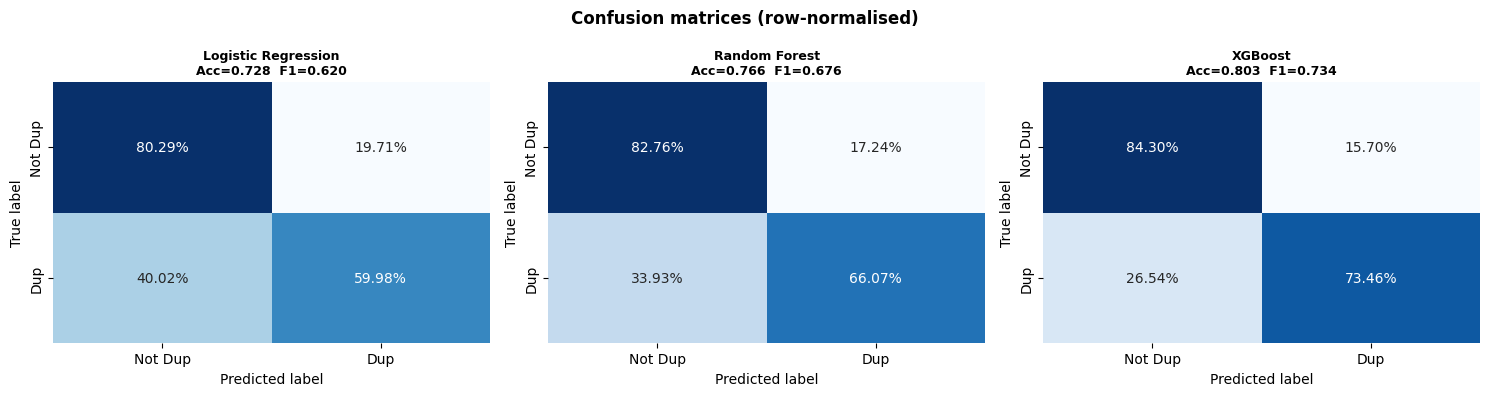

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion matrices (row-normalised)", fontweight="bold")

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r["y_pred"]).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Not Dup","Dup"],
                yticklabels=["Not Dup","Dup"])
    ax.set_title(f"{name}\nAcc={r['acc']:.3f}  F1={r['f1']:.3f}",
                 fontweight="bold", fontsize=9)
    ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")

plt.tight_layout()
plt.savefig("/content/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Plots ROC curves for all three models and calibration curves to check
# whether predicted probabilities are reliable (not just raw scores).

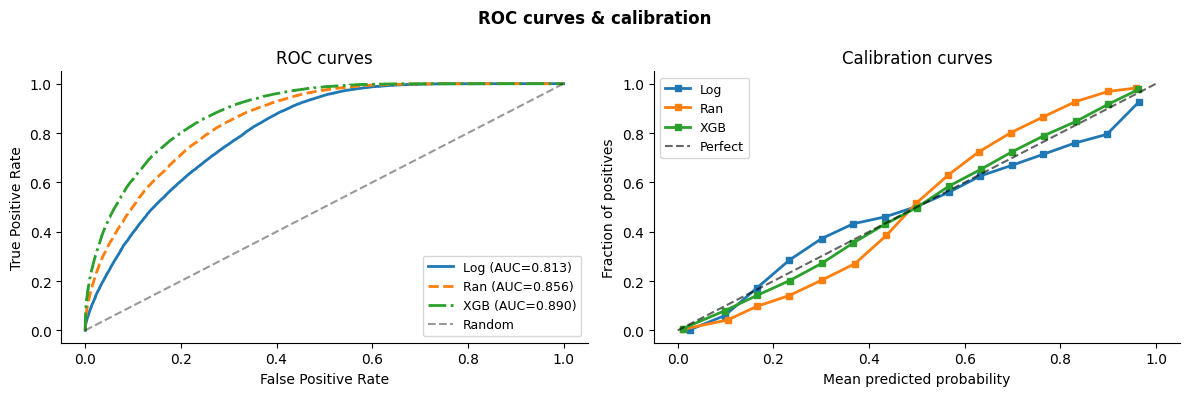

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ROC curves & calibration", fontweight="bold")

# ROC
ax = axes[0]
for (name, r), ls in zip(results.items(), ["-","--","-."]):
    fpr, tpr, _ = roc_curve(y_val, r["y_proba"])
    ax.plot(fpr, tpr, ls, lw=2, label=f"{name[:3]} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves"); ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

# Calibration
ax = axes[1]
for name, r in results.items():
    fp, mp = calibration_curve(y_val, r["y_proba"], n_bins=15)
    ax.plot(mp, fp, "s-", lw=2, markersize=4, label=name[:3])
ax.plot([0,1],[0,1],"k--", alpha=0.6, label="Perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curves"); ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/roc_calibration.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Plots XGBoost's top 15 features by importance and the predicted probability
# distribution to see how well the model separates the two classes.

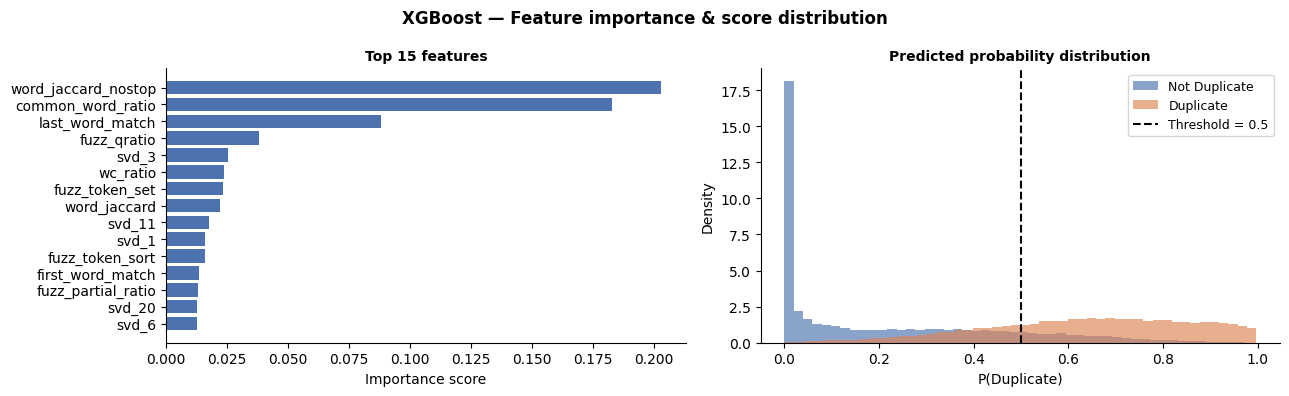

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("XGBoost — Feature importance & score distribution", fontweight="bold")

# feature importance
ax = axes[0]
feat_names = list(X.columns)
imp        = xgb_model.feature_importances_
top_idx    = np.argsort(imp)[-15:]
ax.barh([feat_names[i] for i in top_idx], imp[top_idx], color="#4C72B0")
ax.set_title("Top 15 features", fontweight="bold", fontsize=10)
ax.set_xlabel("Importance score")
ax.spines[["top","right"]].set_visible(False)

# score distribution
ax = axes[1]
ax.hist(xgb_proba[y_val==0], bins=50, alpha=0.65, density=True,
        label="Not Duplicate", color="#4C72B0")
ax.hist(xgb_proba[y_val==1], bins=50, alpha=0.65, density=True,
        label="Duplicate",     color="#DD8452")
ax.axvline(0.5, color="black", ls="--", lw=1.5, label="Threshold = 0.5")
ax.set_title("Predicted probability distribution", fontweight="bold", fontsize=10)
ax.set_xlabel("P(Duplicate)"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/xgb_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

## **SECTION H: TEST PREDICTION**

In [ ]:
# Loads test.csv from the ZIP. test.csv sits directly in the outer archive

In [ ]:
def load_test_csv(zip_path):
    with zipfile.ZipFile(zip_path, "r") as outer:
        name = "test.csv" if "test.csv" in outer.namelist() else "test.csv.zip"
        if name == "test.csv":
            with outer.open("test.csv") as f:
                return pd.read_csv(f)
        with outer.open("test.csv.zip") as raw:
            with zipfile.ZipFile(io.BytesIO(raw.read())) as inner:
                with inner.open("test.csv") as f:
                    return pd.read_csv(f)

test_df = load_test_csv(ZIP_PATH)
test_df["question1"] = test_df["question1"].fillna("")
test_df["question2"] = test_df["question2"].fillna("")

print(f"✓ test.csv loaded")
print(f"   Shape   : {test_df.shape}")
print(f"   Columns : {list(test_df.columns)}")
test_df.head(3)

✓ test.csv loaded
   Shape   : (2345796, 3)
   Columns : ['test_id', 'question1', 'question2']


,test_id,question1,question2
0,0,How does the Surface Pro himself 4 compare wit...,Why did Microsoft choose core m3 and not core ...
1,1,Should I have a hair transplant at age 24? How...,How much cost does hair transplant require?
2,2,What but is the best way to send money from Ch...,What you send money to China?


In [ ]:
# Cleans test question text and builds the fast (vectorised + word-overlap)
# features. Uses the same functions defined for train.

In [ ]:
print("Cleaning test text...")
test_df["q1_clean"] = test_df["question1"].apply(clean_text)
test_df["q2_clean"] = test_df["question2"].apply(clean_text)

print("Building length features...")
len_feats_test = length_features(test_df)

print("Building word-overlap features (~2 min)...")
overlap_feats_test = overlap_features(test_df)

print(f"✓ Fast features done : {len_feats_test.shape[1] + overlap_feats_test.shape[1]} columns")

Cleaning test text...
Building length features...
Building word-overlap features (~2 min)...


  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

✓ Fast features done : 13 columns


In [ ]:
# Builds fuzzy features on the test set.
# This is the longest step — 2.3M rows × 5 fuzzy metrics ≈ 15 min.
# Progress bars track time remaining.

In [ ]:
print("Building fuzzy features on test (~15 min for 2.3M rows)...")
fuzzy_feats_test = fuzzy_features(test_df)
print(f"✓ Fuzzy features done : {fuzzy_feats_test.shape}")

Building fuzzy features on test (~15 min for 2.3M rows)...


  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

  0%|          | 0/2345796 [00:00<?, ?it/s]

✓ Fuzzy features done : (2345796, 5)


In [ ]:
# Applies the FITTED TF-IDF and SVD to the test set (transform only —
# never re-fit on test data, that would cause data leakage).

In [ ]:
combined_test  = (test_df["q1_clean"] + " " + test_df["q2_clean"]).astype(str)
tfidf_mat_test = tfidf.transform(combined_test)       # transform only
svd_arr_test   = svd.transform(tfidf_mat_test)        # transform only

svd_feats_test = pd.DataFrame(
    svd_arr_test,
    columns=[f"svd_{i}" for i in range(30)],
    index=test_df.index
)

X_test = pd.concat([
    len_feats_test,
    overlap_feats_test,
    fuzzy_feats_test,
    svd_feats_test
], axis=1).fillna(0)

print(f"✓ Test feature matrix : {X_test.shape}")
print(f"   Column order matches train : {list(X_test.columns) == list(X.columns)}")

✓ Test feature matrix : (2345796, 48)
   Column order matches train : True


In [ ]:
# Uses the best model (XGBoost) to predict on test, builds the submission
# dataframe, runs format checks, and saves submission.csv to /content/.

In [ ]:
test_preds = xgb_model.predict(X_test.values)

submission = pd.DataFrame({
    "test_id":      test_df["test_id"],
    "is_duplicate": test_preds
})

# ── format validation ──
assert list(submission.columns) == ["test_id", "is_duplicate"], "Wrong column names"
assert submission["is_duplicate"].isin([0,1]).all(),             "Labels must be 0 or 1"
assert len(submission) == len(test_df),                          "Row count mismatch"

submission.to_csv("/content/submission.csv", index=False)

print("✓ submission.csv saved → /content/submission.csv")
print(f"\n   Rows        : {len(submission):,}")
print(f"   Predicted 0  : {(submission['is_duplicate']==0).sum():,}")
print(f"   Predicted 1  : {(submission['is_duplicate']==1).sum():,}")
print(f"   Duplicate %  : {submission['is_duplicate'].mean()*100:.1f}%")
print(f"\n{submission.head(10).to_string(index=False)}")

✓ submission.csv saved → /content/submission.csv

   Rows        : 2,345,796
   Predicted 0  : 1,915,580
   Predicted 1  : 430,216
   Duplicate %  : 18.3%

 test_id  is_duplicate
       0             0
       1             0
       2             0
       3             0
       4             1
       5             0
       6             1
       7             1
       8             1
       9             0
